## **<font color="red">Ridge Regression Using the Gradient Descent</font>**

### ***<font color="Green">Method 01: SGDRegressor</font>***

R2_Score: 0.3360923807078233
Bias (Intercept): [145.08690488]
Weights (Coefficient): [628.96001723]


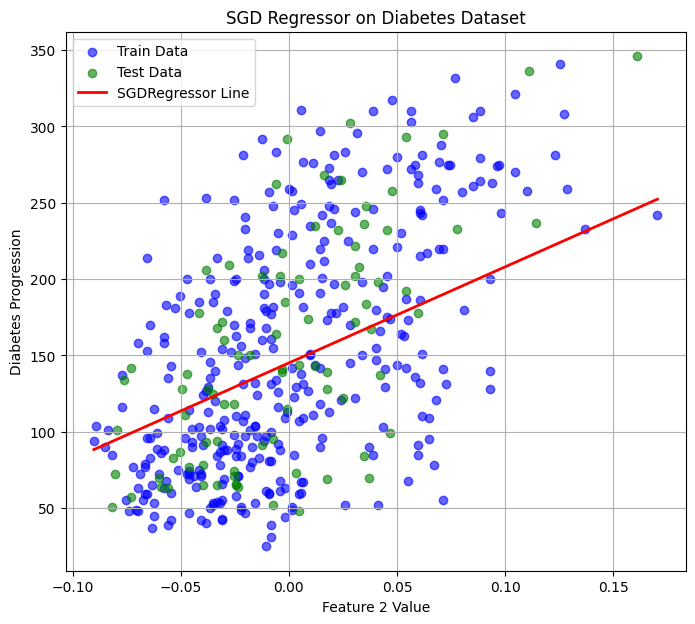

In [20]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

# ===============================
# Load Dataset
# ===============================
X, y = load_diabetes(return_X_y=True)

# Use only one feature for visualization (e.g., feature 2)
X = X[:, 2].reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# ===============================
# Model Training
# ===============================
reg = SGDRegressor(
    penalty='l2',
    max_iter=500,
    eta0=0.1,
    learning_rate='constant',
    alpha=0.001,
    random_state=42)

reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

# ===============================
# Evaluation
# ===============================
print("R2_Score:", r2_score(y_test, y_pred))
print("Bias (Intercept):", reg.intercept_)
print("Weights (Coefficient):", reg.coef_)

# ===============================
# Plot Results
# ===============================
plt.figure(figsize=(8, 7))

# Plot training data
plt.scatter(X_train, y_train, color="blue", alpha=0.6, label="Train Data")

# Plot test data
plt.scatter(X_test, y_test, color="green", alpha=0.6, label="Test Data")

# Plot regression line
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = reg.predict(X_line)
plt.plot(X_line, y_line, color="red", linewidth=2, label="SGDRegressor Line")

plt.title("SGD Regressor on Diabetes Dataset")
plt.xlabel("Feature 2 Value")
plt.ylabel("Diabetes Progression")
plt.legend()
plt.grid(True)
plt.show()


### ***<font color="Green">Method 02: Ridge Regressor</font>***
- solvers:
- - OLS(Ordinary Least Squire) : `svd`, `cholesky`, `lsqr`
  - GD(Gradient Descent): `sparse_cg`, `sag`, `saga`

R2_Score: 0.4159581662676155
Bias (Intercept): 151.18828529959566
Weights (Coefficient): [922.38757866]


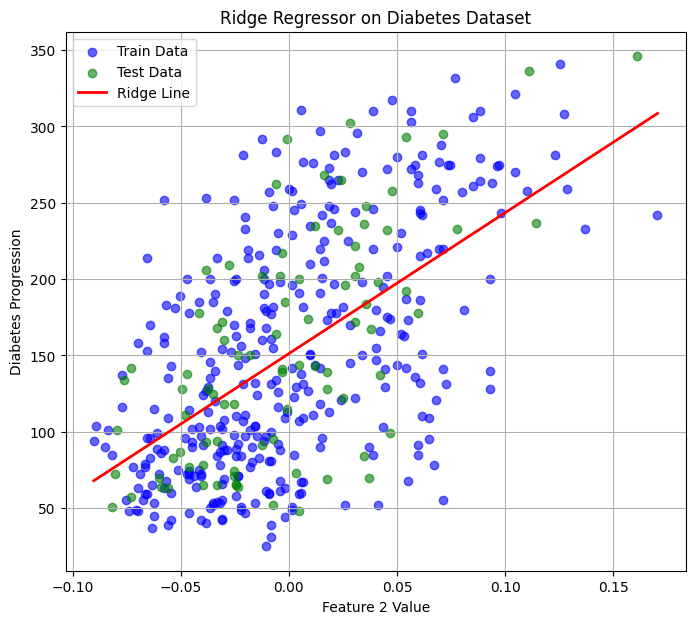

In [22]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# ===============================
# Load Dataset
# ===============================
X, y = load_diabetes(return_X_y=True)

# Use only one feature for visualization (e.g., feature 2)
X = X[:, 2].reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)

# ===============================
# Model Training
# ===============================
reg = Ridge(alpha=0.001,
            max_iter=500,
            solver='sparse_cg')

reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

# ===============================
# Evaluation
# ===============================
print("R2_Score:", r2_score(y_test, y_pred))
print("Bias (Intercept):", reg.intercept_)
print("Weights (Coefficient):", reg.coef_)

# ===============================
# Plot Results
# ===============================
plt.figure(figsize=(8, 7))

# Plot training data
plt.scatter(X_train, y_train, color="blue", alpha=0.6, label="Train Data")

# Plot test data
plt.scatter(X_test, y_test, color="green", alpha=0.6, label="Test Data")

# Plot regression line
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = reg.predict(X_line)
plt.plot(X_line, y_line, color="red", linewidth=2, label="Ridge Line")

plt.title("Ridge Regressor on Diabetes Dataset")
plt.xlabel("Feature 2 Value")
plt.ylabel("Diabetes Progression")
plt.legend()
plt.grid(True)
plt.show()


### ***<font color="Green">Method 03: Custom Class</font>***

R2 Score: 0.4160753079617453
Intercept: 151.63172804532437
Coefficients: [44.46404924]


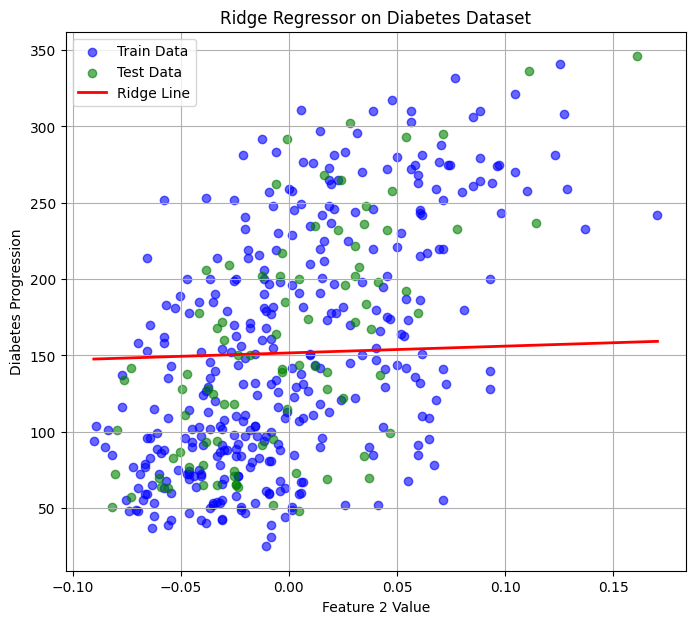

In [62]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Load Dataset
# ===============================
X, y = load_diabetes(return_X_y=True)

# Use only one feature for visualization (e.g., feature 2)
X = X[:, 2].reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)

# -----------------------------
# Custom Ridge Class
# -----------------------------
class CustomGDRidge:
    def __init__(self, epochs=1000, learning_rate=0.01, alpha=0.1):
        self._epochs = epochs
        self._learning_rate = learning_rate
        self._alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, y_train):
        _samples, _features = X_train.shape
        X_b = np.c_[np.ones((_samples, 1)), X_train]  # add bias
        θ = np.zeros(_features + 1)
        for i in range(self._epochs):
            preds = X_b.dot(θ)
            error = preds - y_train
            grad = (X_b.T.dot(error) + self._alpha * np.r_[0, θ[1:]]) / _samples
            θ -= self._learning_rate * grad
        self.intercept_ = θ[0]
        self.coef_ = θ[1:]

    def predict(self, X_test):
        return X_test.dot(self.coef_) + self.intercept_

# -----------------------------
# Standardize features (for stable GD)
# -----------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# -----------------------------
# Train Custom Ridge Model
# -----------------------------
model = CustomGDRidge(epochs=10000, learning_rate=0.01, alpha=0.01)
model.fit(X_train_s, y_train)

# -----------------------------
# Predict & Evaluate
# -----------------------------
y_pred = model.predict(X_test_s)
print("R2 Score:", r2_score(y_test, y_pred))
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# ===============================
# Plot Results
# ===============================
plt.figure(figsize=(8, 7))

# Plot training data
plt.scatter(X_train, y_train, color="blue", alpha=0.6, label="Train Data")

# Plot test data
plt.scatter(X_test, y_test, color="green", alpha=0.6, label="Test Data")

# Plot regression line
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color="red", linewidth=2, label="Ridge Line")

plt.title("Ridge Regressor on Diabetes Dataset")
plt.xlabel("Feature 2 Value")
plt.ylabel("Diabetes Progression")
plt.legend()
plt.grid(True)
plt.show()